# Module 2

### Calling the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Preparing the dataset

In [2]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [3]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 
                'model_year', 'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

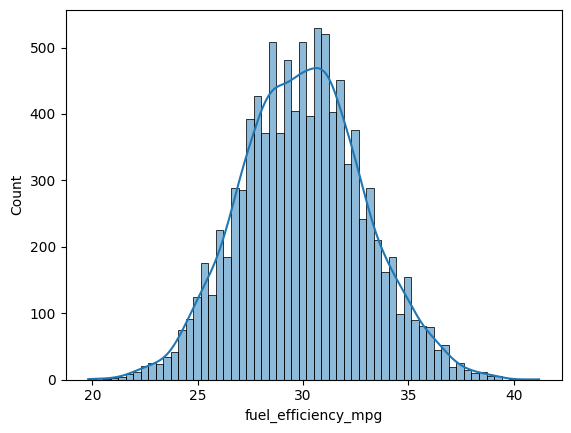

In [4]:
sns.histplot(data=df['fuel_efficiency_mpg'], kde=True)

### Question 1

In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 2

In [6]:
df['horsepower'].median()

np.float64(254.0)

## Prepare and Split the Dataset

In [7]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train.isnull().sum()


engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 3

We are going to train the model with the mean and 0 on the null values.

First, we import the training function from **class 2.7**.

In [8]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

Create both train datasets.

In [20]:
df_train_zero = df_train.copy()
df_train_mean = df_train.copy()


df_train_zero = df_train_zero.fillna(0)

horsepower_train_mean = df_train['horsepower'].mean()
df_train_mean = df_train_mean.fillna(horsepower_train_mean)

df_train_zero.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,0.0,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


Now train the model with each one.

In [21]:
w0_zero, w_zero = train_linear_regression(df_train_zero.drop('fuel_efficiency_mpg', axis=1), 
                                          df_train_zero['fuel_efficiency_mpg'])

w0_mean, w_mean = train_linear_regression(df_train_mean.drop('fuel_efficiency_mpg', axis=1),
                                          df_train_mean['fuel_efficiency_mpg'])

print(w0_zero, w_zero )
print('\n')
print(w0_mean, w_mean)


-153.8849618823138 [-1.51505520e-03 -4.74024794e-06 -3.95418397e-03  1.02146785e-01]


-153.2964563916879 [-0.00102386 -0.00648622 -0.00388828  0.10197897]


Now lets import the RMSE function from **class 2.9**.

In [22]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

First we replace the values as before but now with the validation data and make the predictions.

In [26]:
df_val_zero = df_val.copy()
df_val_mean = df_val.copy()


df_val_zero = df_val_zero.fillna(0)

horsepower_val_mean = df_val['horsepower'].mean()
df_val_mean = df_val_mean.fillna(horsepower_val_mean)

In [32]:
y_zero = df_val_zero['fuel_efficiency_mpg']
y_pred_zero = w0_zero + df_val_zero.drop('fuel_efficiency_mpg', axis=1).dot(w_zero)

y_mean = df_val_mean['fuel_efficiency_mpg']
y_pred_mean = w0_mean + df_val_mean.drop('fuel_efficiency_mpg', axis=1).dot(w_mean)

Calculate the RMSE for each.

In [34]:
RMSE_zero = round(rmse(y_zero, y_pred_zero), 3)
RMSE_mean = round(rmse(y_mean, y_pred_mean), 3)

print(f'RSME replacing with zero: {RMSE_zero}')
print(f'RSME replacing with mean: {RMSE_mean}')

RSME replacing with zero: 2.205
RSME replacing with mean: 2.202


### Question 4